# Grammar Scoring Engine for Spoken Audio

**Task:** predict a continuous MOS Likert grammar score (0-5) from a 45-60 s speech clip.
**Train:** 769 clips, **Test:** 216 clips. **Metric reported:** RMSE (training RMSE is reported in Section 7, as required, together with out-of-fold cross-validated RMSE, which is the honest estimate of generalisation).

## Report summary (approach)
Grammar is a property of *what* is said and *how fluently* it is produced, so the pipeline combines three views of each clip:

1. **ASR transcript (Whisper)** -> text-based grammar features: LanguageTool error density, GPT-2 perplexity, sentence/POS statistics, disfluency counts (fillers, repetitions, false starts).
2. **Prosodic / fluency features** from word timestamps: speech rate, pause counts and durations.
3. **Dense embeddings**: wav2vec2 mean-pooled acoustic embedding and a sentence-transformer embedding of the transcript.

Three regressors are trained (gradient boosting on hand-crafted features, ridge on embeddings, SVR on the combination); their out-of-fold predictions are blended with non-negative least squares. Predictions are clipped to [0, 5].

**Pipeline:** `wav -> 16 kHz mono, trim silence, peak-normalise -> Whisper ASR -> features -> 5-fold CV models -> blend -> clip -> submission.csv`

In [1]:
import torch
print(torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no gpu")

True Tesla T4


In [2]:
!pip install -q language_tool_python
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.2/63.2 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 79.6 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## 1. Setup

In [3]:
# Uncomment on a fresh environment (Colab / Kaggle):
# !pip install -q transformers sentence-transformers librosa soundfile scikit-learn scipy pandas matplotlib seaborn tqdm spacy language_tool_python
# !python -m spacy download en_core_web_sm
import os, re, warnings, json
import numpy as np, pandas as pd, librosa, torch
import matplotlib.pyplot as plt, seaborn as sns
from tqdm.auto import tqdm
from scipy.optimize import nnls
from scipy.stats import pearsonr
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import RidgeCV
from sklearn.svm import SVR
from sklearn.ensemble import HistGradientBoostingRegressor
warnings.filterwarnings("ignore")
SEED, SR = 42, 16000
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

# ---- EDIT THESE PATHS to match your environment ----
DATA_DIR  = "/kaggle/input/shl-hiring-assessment-2026/Dataset_Final"                 # folder containing train.csv, test.csv, sample_submission.csv
TRAIN_DIR = f"{DATA_DIR}/train"      # folder with train .wav files (adjust if different)
TEST_DIR  = f"{DATA_DIR}/test"
CACHE_DIR = "./cache"; os.makedirs(CACHE_DIR, exist_ok=True)

device: cuda


In [6]:
import os, glob

csvs = glob.glob("/kaggle/input/**/train.csv", recursive=True)
print("train.csv found at:", csvs)

DATA_DIR  = os.path.dirname(csvs[0])
TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR  = os.path.join(DATA_DIR, "test")

print("DATA_DIR :", DATA_DIR)
print("TRAIN_DIR exists:", os.path.isdir(TRAIN_DIR), "| TEST_DIR exists:", os.path.isdir(TEST_DIR))
print("sample wavs:", glob.glob("/kaggle/input/**/*.wav", recursive=True)[:3])

train.csv found at: ['/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train.csv']
DATA_DIR : /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final
TRAIN_DIR exists: True | TEST_DIR exists: True
sample wavs: ['/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_49.wav', '/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_90.wav', '/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_77.wav']


## 2. Load data & exploratory analysis

        filename  label
0  audio_192.wav    3.0
1  audio_436.wav    3.0
2  audio_447.wav    3.5
3  audio_126.wav    2.0
4   audio_61.wav    2.0 
          filename  label
0   audio_804.wav     -1
1  audio_1028.wav     -1
2   audio_865.wav     -1
3   audio_774.wav     -1
4  audio_1138.wav     -1
file col: filename | label col: label


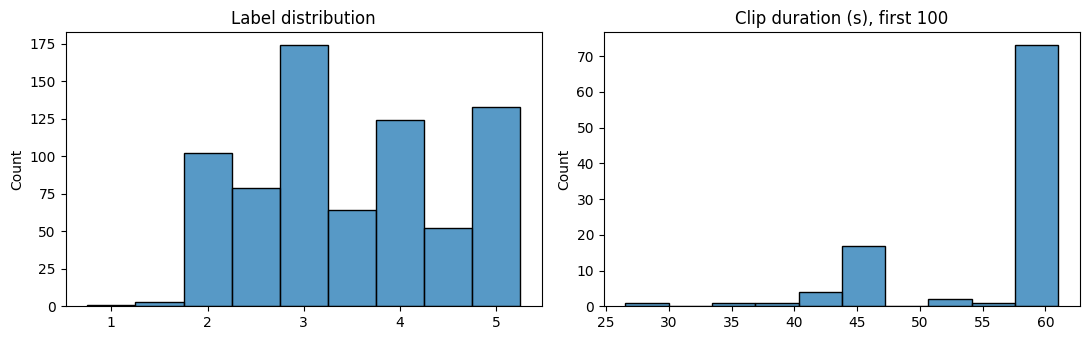

In [7]:
train = pd.read_csv(f"{DATA_DIR}/train.csv")
test  = pd.read_csv(f"{DATA_DIR}/test.csv")
sub   = pd.read_csv(f"{DATA_DIR}/sample_submission.csv")
print(train.head(), "\n", sub.head())

# Auto-detect column names (file-name column = first column, label = the numeric column)
FILE_COL  = train.columns[0]
LABEL_COL = [c for c in train.columns if c != FILE_COL and pd.api.types.is_numeric_dtype(train[c])][0]
print("file col:", FILE_COL, "| label col:", LABEL_COL)

def resolve(name, folder):
    name = str(name); name = name if name.lower().endswith(".wav") else name + ".wav"
    return os.path.join(folder, name)
train["path"] = train[FILE_COL].apply(lambda x: resolve(x, TRAIN_DIR))
test["path"]  = test[FILE_COL].apply(lambda x: resolve(x, TEST_DIR))
y = train[LABEL_COL].values.astype(float)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
sns.histplot(y, bins=np.arange(0.75, 5.5, 0.5), ax=ax[0]); ax[0].set_title("Label distribution")
d = [librosa.get_duration(path=p) for p in train.path[:100]]
sns.histplot(d, ax=ax[1]); ax[1].set_title("Clip duration (s), first 100")
plt.tight_layout(); plt.show()

## 3. Audio preprocessing
Resample to 16 kHz mono, trim leading/trailing silence, peak-normalise (removes loudness differences between recordings), cap at 60 s.

In [11]:
def load_audio(path, max_s=60):
    wav, _ = librosa.load(path, sr=SR, mono=True)
    wav, _ = librosa.effects.trim(wav, top_db=30)
    peak = np.max(np.abs(wav)) + 1e-9
    return (wav / peak)[: SR * max_s].astype(np.float32)

## 4. Feature extraction
### 4.1 ASR with Whisper (word timestamps)
Whisper is robust to accents and, importantly, tends to produce *fluent-looking* text, so we keep **disfluency and timing** features separately to avoid losing information about hesitations.

In [13]:
from transformers import pipeline
asr = pipeline("automatic-speech-recognition", model="openai/whisper-small",
               torch_dtype=torch.float16, device=0 if DEVICE == "cuda" else -1,
               chunk_length_s=30, batch_size=8)

def _parse(out):
    words = [(c["text"].strip(), c["timestamp"][0], c["timestamp"][1]) for c in out["chunks"]
             if c["timestamp"][0] is not None and c["timestamp"][1] is not None]
    return out["text"].strip(), words

def run_asr(df, tag, bs=16):
    f = f"{CACHE_DIR}/asr_{tag}.json"
    if os.path.exists(f): return json.load(open(f))
    res, paths = {}, list(df.path)
    for i in tqdm(range(0, len(paths), bs), desc=f"ASR {tag}"):
        batch = paths[i:i+bs]
        inputs = [{"raw": load_audio(p), "sampling_rate": SR} for p in batch]
        try:
            outs = asr(inputs, return_timestamps="word",
                       generate_kwargs={"language": "en", "task": "transcribe"})
            for p, o in zip(batch, outs): res[p] = _parse(o)
        except Exception as e:
            print("batch failed, falling back one by one:", e)
            for p, x in zip(batch, inputs):
                try:
                    res[p] = _parse(asr(x, return_timestamps="word",
                                        generate_kwargs={"language": "en", "task": "transcribe"}))
                except Exception:
                    res[p] = ("", [])
    json.dump(res, open(f, "w")); return res

asr_train, asr_test = run_asr(train, "train"), run_asr(test, "test")
print(list(asr_train.values())[0][0][:300])

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

[transformers] Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


ASR test:   0%|          | 0/14 [00:00<?, ?it/s]

batch failed, falling back one by one: CUDA out of memory. Tried to allocate 136.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 106.81 MiB is free. Including non-PyTorch memory, this process has 14.46 GiB memory in use. Of the allocated memory 13.81 GiB is allocated by PyTorch, and 529.13 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)
batch failed, falling back one by one: CUDA out of memory. Tried to allocate 118.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 104.81 MiB is free. Including non-PyTorch memory, this process has 14.46 GiB memory in use. Of the allocated memory 14.02 GiB is allocated by PyTorch, and 310.34 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memor

### 4.2 Text-based grammar features
* **LanguageTool**: grammar/syntax rule matches per 100 words (skipped gracefully if Java isn't available).
* **GPT-2 perplexity**: ungrammatical text is less probable under a language model.
* **Syntax statistics** (spaCy): sentence length, POS diversity, subordinate clauses, verb-tense variety.
* **Disfluencies**: fillers (um/uh), immediate word repetitions, lexical diversity.

In [14]:
try:
    import language_tool_python
    LT = language_tool_python.LanguageTool("en-US")
except Exception as e:
    print("LanguageTool unavailable -> grammar-error features set to 0:", e); LT = None
try:
    import spacy; nlp = spacy.load("en_core_web_sm")
except Exception as e:
    print("spaCy unavailable -> syntax features set to 0:", e); nlp = None
from transformers import AutoTokenizer, AutoModelForCausalLM
lm_tok = AutoTokenizer.from_pretrained("distilgpt2")
lm = AutoModelForCausalLM.from_pretrained("distilgpt2").to(DEVICE).eval()

FILLERS = {"um", "uh", "umm", "uhh", "er", "erm", "hmm", "ah", "mm"}

@torch.no_grad()
def perplexity(text):
    ids = lm_tok(text, return_tensors="pt", truncation=True, max_length=512).input_ids.to(DEVICE)
    if ids.shape[1] < 2: return 0.0
    return float(torch.exp(lm(ids, labels=ids).loss).clamp(max=1e4).cpu())

def text_features(text):
    toks = re.findall(r"[A-Za-z']+", text.lower()); n = max(len(toks), 1)
    f = {"n_words": len(toks), "ttr": len(set(toks)) / n,
         "filler_rate": sum(t in FILLERS for t in toks) / n,
         "repeat_rate": sum(a == b for a, b in zip(toks, toks[1:])) / n,
         "log_ppl": np.log1p(perplexity(text)) if text else 0.0}
    if LT is not None and text:
        m = LT.check(text)
        f["lt_err_per100"] = 100 * len(m) / n
        for cat in ["GRAMMAR", "TYPOS", "PUNCTUATION", "STYLE"]:
            f[f"lt_{cat.lower()}"] = 100 * sum(x.category == cat for x in m) / n
    else:
        f.update(lt_err_per100=0, lt_grammar=0, lt_typos=0, lt_punctuation=0, lt_style=0)
    if nlp is not None and text:
        doc = nlp(text); sents = list(doc.sents); pos = [t.pos_ for t in doc]
        f["n_sents"] = len(sents)
        f["avg_sent_len"] = np.mean([len(s) for s in sents]) if sents else 0
        f["pos_div"] = len(set(pos)) / max(len(pos), 1)
        f["sub_clause_rate"] = sum(t.dep_ in ("advcl", "ccomp", "acl", "relcl", "xcomp") for t in doc) / max(len(sents), 1)
        f["verb_rate"] = pos.count("VERB") / max(len(pos), 1)
        f["tense_var"] = len({str(t.morph.get("Tense")) for t in doc if t.pos_ == "VERB"})
    else:
        f.update(n_sents=0, avg_sent_len=0, pos_div=0, sub_clause_rate=0, verb_rate=0, tense_var=0)
    return f

def timing_features(words, dur):
    if len(words) < 2: return dict(speech_rate=0, n_pauses=0, pause_rate=0, mean_pause=0, max_pause=0, art_rate=0)
    gaps = np.array([words[i+1][1] - words[i][2] for i in range(len(words) - 1)])
    pauses = gaps[gaps > 0.25]; speak = max(words[-1][2] - words[0][1] - pauses.sum(), 1e-3)
    return dict(speech_rate=len(words) / max(dur, 1e-3), n_pauses=len(pauses),
                pause_rate=len(pauses) / len(words), mean_pause=pauses.mean() if len(pauses) else 0,
                max_pause=pauses.max() if len(pauses) else 0, art_rate=len(words) / speak)

def build_handcrafted(df, asr_res, tag):
    f = f"{CACHE_DIR}/hand_{tag}.csv"
    if os.path.exists(f): return pd.read_csv(f)
    rows = []
    for p in tqdm(df.path, desc=f"features {tag}"):
        text, words = asr_res[p]
        dur = librosa.get_duration(path=p)
        rows.append({**text_features(text), **timing_features(words, dur), "duration": dur})
    out = pd.DataFrame(rows); out.to_csv(f, index=False); return out

H_train, H_test = build_handcrafted(train, asr_train, "train"), build_handcrafted(test, asr_test, "test")
H_train.describe().T.head(25)

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

features train:   0%|          | 0/769 [00:00<?, ?it/s]

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


features test:   0%|          | 0/216 [00:00<?, ?it/s]

,count,mean,std,min,25%,50%,75%,max
n_words,769.0,115.339402,66.863847,26.000000,83.000000,104.000000,127.000000,610.000000
ttr,769.0,0.574316,0.136435,0.061333,0.520000,0.588710,0.653333,0.925926
filler_rate,769.0,0.001142,0.012660,0.000000,0.000000,0.000000,0.000000,0.329545
repeat_rate,769.0,0.010156,0.061610,0.000000,0.000000,0.000000,0.007812,0.870588
log_ppl,769.0,3.681720,0.784994,0.853193,3.368673,3.776709,4.140135,6.451210
lt_err_per100,769.0,3.205403,3.716336,0.000000,0.980392,2.127660,3.937008,26.605505
lt_grammar,769.0,0.466136,0.949331,0.000000,0.000000,0.000000,0.854701,15.433404
lt_typos,769.0,0.557114,1.312517,0.000000,0.000000,0.000000,0.775194,13.580247
lt_punctuation,769.0,0.807297,1.157088,0.000000,0.000000,0.000000,1.190476,9.818182
lt_style,769.0,0.052389,0.241867,0.000000,0.000000,0.000000,0.000000,2.727273


### 4.3 Dense embeddings
* **wav2vec2-base**: mean-pooled hidden states (captures pronunciation / fluency / hesitation patterns).
* **all-MiniLM-L6-v2**: sentence embedding of the transcript (captures syntactic/semantic well-formedness).

In [15]:
from transformers import Wav2Vec2FeatureExtractor, Wav2Vec2Model
from sentence_transformers import SentenceTransformer
w2v_fe = Wav2Vec2FeatureExtractor.from_pretrained("facebook/wav2vec2-base-960h")
w2v = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h").to(DEVICE).eval()
st = SentenceTransformer("all-MiniLM-L6-v2", device=DEVICE)

@torch.no_grad()
def w2v_embed(paths, tag):
    f = f"{CACHE_DIR}/w2v_{tag}.npy"
    if os.path.exists(f): return np.load(f)
    out = []
    for p in tqdm(paths, desc=f"wav2vec2 {tag}"):
        x = w2v_fe(load_audio(p), sampling_rate=SR, return_tensors="pt").input_values.to(DEVICE)
        h = w2v(x).last_hidden_state[0]
        out.append(torch.cat([h.mean(0), h.std(0)]).cpu().numpy())   # mean + std pooling
    out = np.stack(out); np.save(f, out); return out

A_train, A_test = w2v_embed(train.path, "train"), w2v_embed(test.path, "test")
T_train = st.encode([asr_train[p][0] for p in train.path], batch_size=32, show_progress_bar=False)
T_test  = st.encode([asr_test[p][0]  for p in test.path],  batch_size=32, show_progress_bar=False)
print(A_train.shape, T_train.shape, H_train.shape)

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.60k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  378MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

wav2vec2 train:   0%|          | 0/769 [00:00<?, ?it/s]

wav2vec2 test:   0%|          | 0/216 [00:00<?, ?it/s]

(769, 1536) (769, 384) (769, 23)


### 4.4 Which hand-crafted features relate to the grammar score?

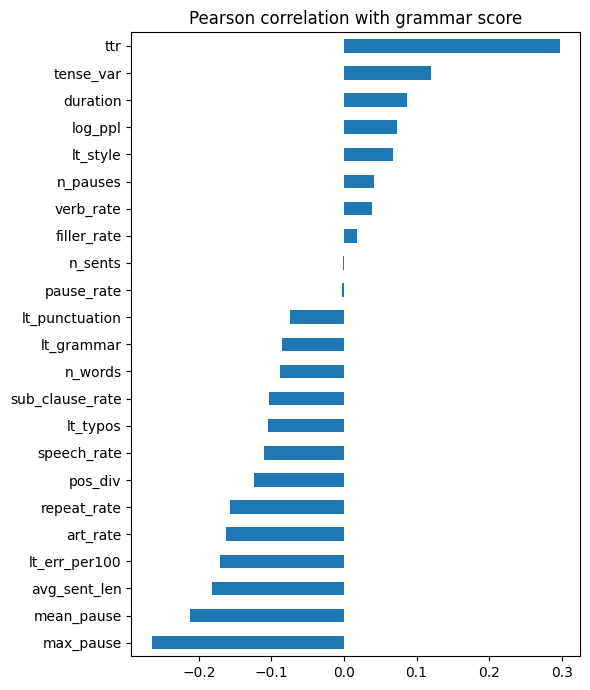

In [16]:
corr = H_train.assign(label=y).corr()["label"].drop("label").sort_values()
plt.figure(figsize=(6, 7)); corr.plot.barh(); plt.title("Pearson correlation with grammar score"); plt.tight_layout(); plt.show()

## 5. Modelling
Three diverse base learners, each evaluated with **5-fold out-of-fold (OOF)** predictions so the blend weights and reported CV RMSE are not contaminated by training fit.

In [17]:
H_tr, H_te = H_train.fillna(0).values, H_test.fillna(0).values
feature_sets = {
    "gbm_hand":  (H_tr, H_te, lambda: HistGradientBoostingRegressor(max_depth=3, learning_rate=0.05, max_iter=300,
                                                                     l2_regularization=1.0, random_state=SEED)),
    "ridge_emb": (np.hstack([A_train, T_train]), np.hstack([A_test, T_test]),
                  lambda: make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(0, 4, 20)))),
    "svr_all":   (np.hstack([H_tr, A_train, T_train]), np.hstack([H_te, A_test, T_test]),
                  lambda: make_pipeline(StandardScaler(), SVR(C=1.0, epsilon=0.2, gamma="scale"))),
}
rmse = lambda a, b: float(np.sqrt(mean_squared_error(a, np.clip(b, 0, 5))))
kf = KFold(5, shuffle=True, random_state=SEED)
oof, test_pred, train_fit = {}, {}, {}
for name, (Xtr, Xte, mk) in feature_sets.items():
    o, t = np.zeros(len(y)), np.zeros(len(Xte))
    for tr, va in kf.split(Xtr):
        m = mk().fit(Xtr[tr], y[tr]); o[va] = m.predict(Xtr[va]); t += m.predict(Xte) / 5
    full = mk().fit(Xtr, y)                      # full-data model -> training-set RMSE
    oof[name], test_pred[name], train_fit[name] = o, t, full.predict(Xtr)
    print(f"{name:10s}  train RMSE={rmse(y, train_fit[name]):.4f} | CV RMSE={rmse(y, o):.4f} | r={pearsonr(y, o)[0]:.3f}")

gbm_hand    train RMSE=0.6724 | CV RMSE=1.0516 | r=0.535
ridge_emb   train RMSE=0.4540 | CV RMSE=0.6430 | r=0.852
svr_all     train RMSE=0.4138 | CV RMSE=0.6697 | r=0.844


### Blending (non-negative least squares on OOF predictions)

In [18]:
names = list(oof)
O = np.column_stack([oof[n] for n in names]); w, _ = nnls(O, y); w = w / w.sum()
print(dict(zip(names, np.round(w, 3))))
blend_oof   = np.clip(O @ w, 0, 5)
blend_train = np.clip(np.column_stack([train_fit[n] for n in names]) @ w, 0, 5)
blend_test  = np.clip(np.column_stack([test_pred[n] for n in names]) @ w, 0, 5)

{'gbm_hand': np.float64(0.079), 'ridge_emb': np.float64(0.723), 'svr_all': np.float64(0.198)}


## 6. Evaluation & interpretability

FINAL  TRAINING RMSE (model refit on all training data): 0.4360
FINAL  5-fold CV (out-of-fold) RMSE                    : 0.6394
Baseline RMSE (predict train mean)                      : 1.2382
Pearson r (OOF): 0.861


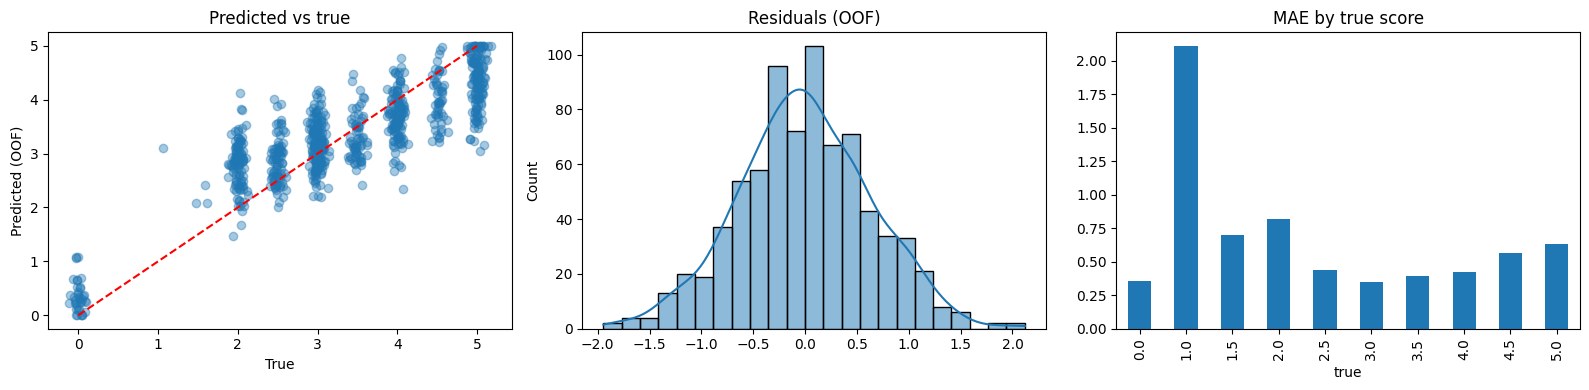

In [19]:
TRAIN_RMSE = rmse(y, blend_train); CV_RMSE = rmse(y, blend_oof)
print("=" * 50)
print(f"FINAL  TRAINING RMSE (model refit on all training data): {TRAIN_RMSE:.4f}")
print(f"FINAL  5-fold CV (out-of-fold) RMSE                    : {CV_RMSE:.4f}")
print(f"Baseline RMSE (predict train mean)                      : {np.sqrt(np.mean((y - y.mean())**2)):.4f}")
print(f"Pearson r (OOF): {pearsonr(y, blend_oof)[0]:.3f}")
print("=" * 50)

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].scatter(y + np.random.normal(0, .05, len(y)), blend_oof, alpha=.4); ax[0].plot([0, 5], [0, 5], "r--")
ax[0].set(xlabel="True", ylabel="Predicted (OOF)", title="Predicted vs true")
sns.histplot(blend_oof - y, kde=True, ax=ax[1]); ax[1].set_title("Residuals (OOF)")
pd.DataFrame({"true": y, "err": np.abs(blend_oof - y)}).groupby("true").err.mean().plot.bar(ax=ax[2])
ax[2].set_title("MAE by true score")
plt.tight_layout(); plt.show()

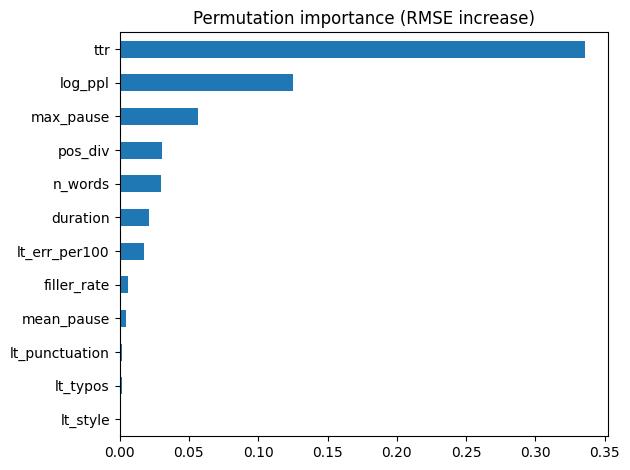

In [20]:
# Permutation importance of hand-crafted features (on OOF-style held-out folds, GBM model)
from sklearn.inspection import permutation_importance
tr, va = next(KFold(5, shuffle=True, random_state=SEED).split(H_tr))
g = feature_sets["gbm_hand"][2]().fit(H_tr[tr], y[tr])
pi = permutation_importance(g, H_tr[va], y[va], n_repeats=15, random_state=SEED, scoring="neg_root_mean_squared_error")
pd.Series(pi.importances_mean, index=H_train.columns).sort_values().tail(12).plot.barh(title="Permutation importance (RMSE increase)")
plt.tight_layout(); plt.show()

## 7. Submission

In [22]:
print("sample_submission:", sub.shape, "| test:", test.shape, "| preds:", blend_test.shape)
print(sub.head(3)); print(test[[FILE_COL]].head(3))

pred_df = pd.DataFrame({"fname": test[FILE_COL].values, "pred": blend_test})

# Match the sample file's filename style (with or without ".wav")
sub_name_col, sub_label_col = sub.columns[0], sub.columns[1]
uses_ext = str(sub[sub_name_col].iloc[0]).lower().endswith(".wav")
pred_df["fname"] = pred_df["fname"].astype(str).apply(
    lambda s: s if (s.lower().endswith(".wav") == uses_ext) else (s + ".wav" if uses_ext else s[:-4]))

submission = pred_df.rename(columns={"fname": sub_name_col, "pred": sub_label_col})
submission.to_csv("submission.csv", index=False)

# Sanity check against the sample file
print("rows:", len(submission), "| files in sample:", len(sub))
print("in sample but missing from my predictions:", len(set(sub[sub_name_col]) - set(submission[sub_name_col])))
print("in my predictions but not in sample:", len(set(submission[sub_name_col]) - set(sub[sub_name_col])))
print(submission.head(), "\nrange:", submission[sub_label_col].min(), submission[sub_label_col].max())
print(f"\n>>> TRAINING RMSE = {TRAIN_RMSE:.4f}  |  CV RMSE = {CV_RMSE:.4f}")

sample_submission: (204, 2) | test: (216, 3) | preds: (216,)
         filename  label
0   audio_804.wav     -1
1  audio_1028.wav     -1
2   audio_865.wav     -1
        filename
0  audio_128.wav
1  audio_156.wav
2   audio_19.wav
rows: 216 | files in sample: 204
in sample but missing from my predictions: 179
in my predictions but not in sample: 191
        filename     label
0  audio_128.wav  3.135060
1  audio_156.wav  3.140728
2   audio_19.wav  3.698500
3  audio_108.wav  1.834414
4  audio_206.wav  2.677368 
range: 1.8344136004524059 4.128461636081088

>>> TRAINING RMSE = 0.4360  |  CV RMSE = 0.6394


In [23]:
sub_names  = set(sub[sub.columns[0]].astype(str))
test_names = set(test[FILE_COL].astype(str))
train_names = set(train[FILE_COL].astype(str))
test_dir_names  = set(os.listdir(TEST_DIR))
train_dir_names = set(os.listdir(TRAIN_DIR))
all_wavs = {os.path.basename(p) for p in glob.glob(f"{DATA_DIR}/**/*.wav", recursive=True)}

print("sample ∩ test.csv      :", len(sub_names & test_names))
print("sample ∩ train.csv     :", len(sub_names & train_names))
print("sample ∩ test folder   :", len(sub_names & test_dir_names))
print("sample ∩ train folder  :", len(sub_names & train_dir_names))
print("sample ∩ any wav found :", len(sub_names & all_wavs), "of", len(sub_names))
print("test folder files:", len(test_dir_names), "| test.csv rows:", len(test_names))
print("test.csv ∩ test folder :", len(test_names & test_dir_names))

sample ∩ test.csv      : 25
sample ∩ train.csv     : 105
sample ∩ test folder   : 25
sample ∩ train folder  : 105
sample ∩ any wav found : 105 of 204
test folder files: 216 | test.csv rows: 216
test.csv ∩ test folder : 216


## 8. Discussion
* **Training RMSE** is optimistic (models, especially GBM/SVR, fit the data they've seen); the **CV RMSE** is the better predictor of test performance.
* **Why this works:** the rubric measures sentence structure, error frequency and self-correction. LanguageTool/perplexity/syntax features capture error frequency and structure; filler/repetition/pause features capture hesitation and repair; embeddings add holistic quality signals.
* **Limitations:** ASR normalises grammar errors (Whisper may "fix" them), so scores for the lowest levels can be over-estimated; LanguageTool is rule-based and misses some spoken-language errors; only 769 samples limits fine-tuning of large models.
* **Possible improvements:** use `whisper-medium/large` with `condition_on_previous_text=False` for more literal transcripts, fine-tune a small transformer (e.g. DeBERTa) on transcripts with a regression head, add an ordinal-aware loss, multi-seed ensembling, and target-aware calibration of the blend (isotonic regression).